# X - Deepweeds - MobileNetv3Small

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import random
import os
import shutil

tf.__version__

2026-01-16 09:00:40.550435: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-16 09:00:40.550569: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-16 09:00:40.687411: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


'2.15.0'

# Configurations

In [2]:
INFERENCE_DEVICE = 'GPU:0' if len(tf.config.list_physical_devices('GPU')) else 'CPU:0'

################################
###### Configurations #########
##############################
seed = 999
SEED = seed
USE_DETERMINISTIC = True
K_FOLD_INDEX = 0
oversampling = 0 # How many times are we gonna over sample

## Model Configurations
MODEL_NAME=f"MobileNetV3Small_KF{K_FOLD_INDEX+1}.keras"
NUM_SUBSPACE = 16
IMG_SIZE=(224,224,3)
FINAL_FEAT = 1024

## Training Configurations
TRAIN_BATCH_SIZE=32
EPOCHS = 300
ES_PATIENCE = 16 ## Patience Epoch for Early Stopping
ES_MONITOR = 'val_loss'
LR_REDUCTION_FACTOR = 0.8 ## for ReduceLROnPlateau Callback
LR_REDUCTION_PATIENCE = 3 ## Patience for LR Reduction
LR_REDUCTION_MONITOR = 'val_loss'

##### FineTuning Part
INIT_LR1 = 2e-4 ## Initial Learning Rate (AdamW) 
W_DECAY1 = 5e-2 ## Weight Decay
MIN_LR1 = 1e-7 ## Minimum Learning Rate for ReduceLROnPlateau Callback
##
USE_WARMUP = False
WARMUP_EPOCHS = 5
WARMUP_INIT_LR = INIT_LR1 / WARMUP_EPOCHS
WARMUP_MAX_LR = INIT_LR1
WARMUP_INCREMENT_RATE = 0.3

##### Base Model Freezing Part
INIT_LR2 = 2e-5 # Initial Learning Rate for optimizer (AdamW)
W_DECAY2 = 5e-3 ## Weight Decay for optimizer
MIN_LR2 = 1e-9 # Minimum Learning Rate for ReduceLROnPlateau

#### -- Optimizer
USE_ADAMW = '2.15' in tf.__version__
#########################################
isKaggle = 'kaggle' in os.getcwd()

if isKaggle:
    DATASET_PATH = "/kaggle/input/deepweeds"
    IMAGE_DATASET_PATH = "/kaggle/input/deepweeds/images" ## For Kaggle
    DATASET_OUTPUT_PATH = "/kaggle/working/deepweeds_9c" ## For Kaggle
else:
    try:
        DATASET_PATH = reganmaharjan_deepweeds_path
        DATASET_OUTPUT_PATH = '/content/dataset_9c' ## For GoogleColab
        IMAGE_DATASET_PATH = reganmaharjan_deepweeds_path + '/images' ## For GoogleColab
    except:
        DATASET_PATH = ''
        IMAGE_DATASET_PATH = '' ## Assign The Image Path
        DATASET_OUTPUT_PATH = '' ## Assign The path where the Images are to ogranized for Data Generator from Directory


isTPU = False
fixDatasetBatch = False ## if True: duplicates files randomly such that each batch contains same no.of files - Required when isTPU=True.

In [3]:
print("Tensorflow version " + tf.__version__)
if tf.config.list_logical_devices('TPU'):
    if isKaggle:
        # On TPU VMs use this line instead:
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver(tpu="local")  ## if kaggle
    else:        
        resolver = tf.distribute.cluster_resolver.TPUClusterResolver() ## if colab

    tf.config.experimental_connect_to_cluster(resolver)
    tf.tpu.experimental.initialize_tpu_system(resolver)

    #---------
    strategy = tf.distribute.TPUStrategy(resolver)
    print('TPU available')
    isTPU = True
else: ### If GPU or CPU
    if tf.config.list_logical_devices('GPU'): 
        print('GPU available')
    else:
        print("Only CPU available")
       
    # For testing without a TPU use this line instead: 
    # strategy = tf.distribute.OneDeviceStrategy("/cpu:0")
    strategy = tf.distribute.MirroredStrategy()


print("REPLICAS: ", strategy.num_replicas_in_sync)
if isTPU:
    USE_ADAMW = False
    LR_REDUCTION_PATIENCE = 5
    ES_PATIENCE = 27
    print("Use ADAM with TPU")

Tensorflow version 2.15.0
GPU available
REPLICAS:  1


In [4]:
def seedEverything(seed=42, deterministic = False):
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    tf.keras.utils.set_random_seed(seed)
    
    if deterministic:
        tf.config.experimental.enable_op_determinism()
        
        os.environ['TF_DETERMINISTIC_OPS'] = '1'
        os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

        #tf.config.threading.set_inter_op_parallelism_threads(1)
        #tf.config.threading.set_intra_op_parallelism_threads(1)


seedEverything(SEED, USE_DETERMINISTIC)
tf.config.set_soft_device_placement(True)

In [5]:
## Downloading DeepWeeds Data  ## For Google Colab
# url = 'https://drive.google.com/uc?export=download&id=1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj'
# !gdown 1xnK3B6K6KekDI55vwJ0vnc2IGoDga9cj
# !unzip -qq images.zip -d images

In [6]:
try:
    data_info = pd.read_csv(f"{DATASET_PATH}/labels.csv") ## For Kaggle
except:
    data_info = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/labels.csv') ## for GoogleColab
data_info

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple
...,...,...,...
17504,20180322-133822-1.jpg,8,Negative
17505,20180322-133832-1.jpg,8,Negative
17506,20180322-133840-1.jpg,8,Negative
17507,20180322-133850-1.jpg,8,Negative


In [7]:
data_info[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [8]:
label2id = data_info[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [9]:
low_data_labels = data_info[data_info['Species'] != "Negative"]['Label'].unique() ## labels with very low data
low_data_labels

array([0, 1, 7, 6, 4, 3, 5, 2])

# Splitting Data into Train:Valid:Test Splits (60:20:20)

In [10]:
# colabAI prompt: train test split using data_info
from sklearn.model_selection import train_test_split, StratifiedKFold

### K-Fold Validation-----
#####---------------------
split_index = K_FOLD_INDEX # index to retrieve
print("Using KFold: Index",split_index+1,"out of 5 folds")
print("-------------------------------------------------\n")

# skfold = StratifiedKFold()
# kSplits = skfold.split(data_info['Filename'], y=data_info['Label'])

# for index in range(skfold.get_n_splits()):
#     train_index, test_index = next(kSplits)
#     if index == split_index:
#         break

# trax, tex, tray, tey = train_test_split(data_info['Filename'],data_info['Label'], test_size=0.4, random_state=seed)
# train_data = pd.DataFrame({"Filename":trax,"label":tray})

# trax, tex, tray, tey = train_test_split(tex,tey, test_size=0.5, random_state=seed)
# valid_data = pd.DataFrame({"Filename":trax,"label":tray})
# test_data = pd.DataFrame({"Filename":tex,"label":tey})

Using KFold: Index 1 out of 5 folds
-------------------------------------------------



In [11]:
## Using Folds Used in The DeepWeeds Paper
try:
    train_data = pd.read_csv(f'{DATASET_PATH}/train_subset{K_FOLD_INDEX}.csv')
    valid_data = pd.read_csv(f'{DATASET_PATH}/val_subset{K_FOLD_INDEX}.csv')
    test_data = pd.read_csv(f'{DATASET_PATH}/test_subset{K_FOLD_INDEX}.csv')

except:
    train_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/train_subset{}.csv'.format(split_index)) ## for GoogleColab
    valid_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/val_subset{}.csv'.format(split_index)) ## for GoogleColab
    test_data = pd.read_csv('https://raw.githubusercontent.com/AlexOlsen/DeepWeeds/master/labels/test_subset{}.csv'.format(split_index)) ## for GoogleColab

train_data.rename(columns={"Label":"label"}, inplace=True)
valid_data.rename(columns={"Label":"label"}, inplace=True)
test_data.rename(columns={"Label":"label"}, inplace=True)

print("Is There Duplicates: ", not valid_data[valid_data['Filename'].isin(test_data['Filename'])].empty)
print("Train Data\n--------\n",train_data.groupby(by='label').count().T, "\tTotal:", train_data.shape)
print("Validation Data\n--------\n",valid_data.groupby(by='label').count().T, "\tTotal:", valid_data.shape)
print("Test Data\n--------\n",test_data.groupby(by='label').count().T, "\tTotal:", test_data.shape)

Is There Duplicates:  False
Train Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  675  637  618  613  637  605  644  609  5463 	Total: (10501, 2)
Validation Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  225  213  206  204  212  202  215  203  1821 	Total: (3501, 2)
Test Data
--------
 label       0    1    2    3    4    5    6    7     8
Filename  226  213  207  205  213  202  215  204  1822 	Total: (3507, 2)


# Helper Functions

- Organize Images to Directory as per Label for Creating Generator (organize_data_to_directory)
- Dataset Generator (getDatasetGenerators) - works in tandem with "organize_data_to_directory"
- Class Weights For Imbalanced Dataset (getWeightedClass)
- Accuracy / Loss plot (plot_loss_acc)
- Evaluation Metrics Calculation (eval_model, print_stats, calcFalseRate)
- Prediction with Threshold as used by DeepWeeds Author (prediction_argmax)



In [12]:
from tqdm.auto import tqdm

def organize_data_to_directory(data_info,source_dir='',target_dir='',oversample=0, oversampling_labels=[]):
    indices=[]
    if fixDatasetBatch or isTPU:
        batch = TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync
        size = data_info.shape[0]
        remainder = size % batch
        residue = batch - remainder
        rng = np.arange(size)
        np.random.shuffle(rng)
        indices = rng[:residue]
        
    for index, row in tqdm(data_info.iterrows()):
        filename = row['Filename']
        label = row['label']

        source = os.path.join(source_dir,filename)

        #if not os.path.exists(source):
        #    print("File Doesn't Exist", source)
        #    continue

        target_path = os.path.join(target_dir,str(label))
        target = os.path.join(target_path,filename)
        # print(source,target)

        if not os.path.exists(target_path):
            os.mkdir(target_path)

        if not os.path.exists(target):
            if oversample and (label in oversampling_labels):
                for i in range(oversample):
                    sample_filename = os.path.join(target_path, "oversample-"+str(i)+"-"+filename)
                    shutil.copy(source, sample_filename)
            elif index in indices:
                sample_filename = os.path.join(target_path, f"last_batch_fix_{index}-"+filename)
                shutil.copy(source, sample_filename)
                
            shutil.copy(source,target)

##-----------------------------
###----------------------------

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import image_dataset_from_directory

def getDatasetGenerators(train_dir, **kwargs):
    # --------------------
    # Flow training images in batches using generator
    # --------------------
    generator = image_dataset_from_directory(
        train_dir,
        **kwargs
    )

    return generator

In [13]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
import math

def prediction_argmax(prediction, rand_guess=1):
    prediction = np.asarray(prediction)
    l_pred = np.argmax(prediction[low_data_labels])
    if(prediction[l_pred] > rand_guess):
        return l_pred

    return np.argmax(prediction)

def calcFalsePositiveRate(a_label, p_label, label_names=None, n_class=None):
    if n_class is None:
        n_class = len(np.unique(a_label))
    conf_mat = tf.math.confusion_matrix(a_label, p_label, num_classes=n_class).numpy()

    false_rate = []
    total = len(a_label)
    for i in range(n_class):
        tP = conf_mat[i][i]
        fN = np.sum(conf_mat[i,:]) - tP

        fP = np.sum(conf_mat[:,i]) - tP
        tN = total - (tP + fN + fP)

        fP_Rate = fP/(tN+fP)
        # fN_Rate = fN/(tP+fN)
        accuracy = tP / (tP+fN)

        false_rate.append((fP_Rate,accuracy))

    false_rate = pd.DataFrame(false_rate, columns=["False Positive Rate", "Accuracy"], index=label_names)
    return false_rate

def printStats(actual_labels,prediction, use_rand_guess= 0):
    if use_rand_guess:
        prediction = [prediction_argmax(x, rand_guess=use_rand_guess) for x in prediction]
    else:
        prediction = [np.argmax(x) for x in prediction]

    print("Evaluation Metrics\n=================================\n")
    #     print("F1-Score",f1_score(actual_labels,prediction,average='weighted'))
    #     print("Precision-Score",precision_score(actual_labels,prediction,average='weighted'))
    #     print("Recall-Score",recall_score(actual_labels,prediction,average='weighted'))
    #     print("accuracy_Score",accuracy_score(actual_labels,prediction))

    label_names = [id2label[i] for i in range(len(id2label))]
    print(classification_report(actual_labels, prediction,digits=5, target_names=label_names))
    print()
    print(calcFalsePositiveRate(actual_labels, prediction, label_names = label_names))
    print()
    print("Confusion Matrix\n=================================\n")
    n_class = np.unique(actual_labels).shape[0]
    cmd = ConfusionMatrixDisplay.from_predictions(
        actual_labels, prediction,
        display_labels=label_names,
        xticks_rotation=45 #'vertical'
    )
    #cmd.plot()
    plt.show()

def eval_model(model, data_gen, use_rand_guess=False):
    print("model.evaluate")
    model.evaluate(data_gen)

    print("model.predict")
    actual_labels = []
    pred_prob = []
    for batch in tqdm(data_gen):
        actual_labels.extend([np.argmax(z) for z in batch[1]])
        pred_prob.extend(list(model(batch[0], training=False)))

    printStats(actual_labels,pred_prob,use_rand_guess)
    return actual_labels, pred_prob


def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = [0.0 if math.isnan(v) else v for v in history['accuracy']]
    val_acc = [0.0 if math.isnan(v) else v for v in history['val_accuracy']]
    loss = [0.0 if math.isnan(v) else v for v in history['loss']]
    val_loss = [0.0 if math.isnan(v) else v for v in history['val_loss']]
    
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()

    plt.show()

# Creating Dateset ImageGenerator

In [14]:
if oversampling:
    print("Oversampling training set",oversampling,"times for labels",low_data_labels)
else:
    print("No OverSampling")

input_dir = IMAGE_DATASET_PATH
base_dir = DATASET_OUTPUT_PATH

train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

os.mkdir(base_dir)
os.mkdir(train_dir)
os.mkdir(validation_dir)
os.mkdir(test_dir)

## Organizing Training Data
organize_data_to_directory(train_data, source_dir=input_dir, target_dir=train_dir, oversample=oversampling, oversampling_labels=low_data_labels)

# ## Organizing Validation Data
organize_data_to_directory(valid_data, source_dir=input_dir, target_dir=validation_dir)

# ## Organizing Test Data
organize_data_to_directory(test_data, source_dir=input_dir, target_dir=test_dir)

No OverSampling


0it [00:00, ?it/s]

0it [00:00, ?it/s]

0it [00:00, ?it/s]

In [15]:
train_generator = getDatasetGenerators(
      train_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

validation_generator = getDatasetGenerators(
      validation_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=True
)

test_generator = getDatasetGenerators(
      test_dir,
      batch_size=TRAIN_BATCH_SIZE,
      label_mode='categorical',
      image_size = IMG_SIZE[:2],
      shuffle=False
)

with strategy.scope(): 
    if isTPU:  
        train_generator = train_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        validation_generator = validation_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        test_generator = test_generator.rebatch(TRAIN_BATCH_SIZE * strategy.num_replicas_in_sync, drop_remainder=True)
        
    train_generator = train_generator.prefetch(tf.data.AUTOTUNE)
    validation_generator = validation_generator.prefetch(tf.data.AUTOTUNE)
    test_generator = test_generator.prefetch(tf.data.AUTOTUNE)     

Found 10501 files belonging to 9 classes.
Found 3501 files belonging to 9 classes.
Found 3507 files belonging to 9 classes.


# Sample Images

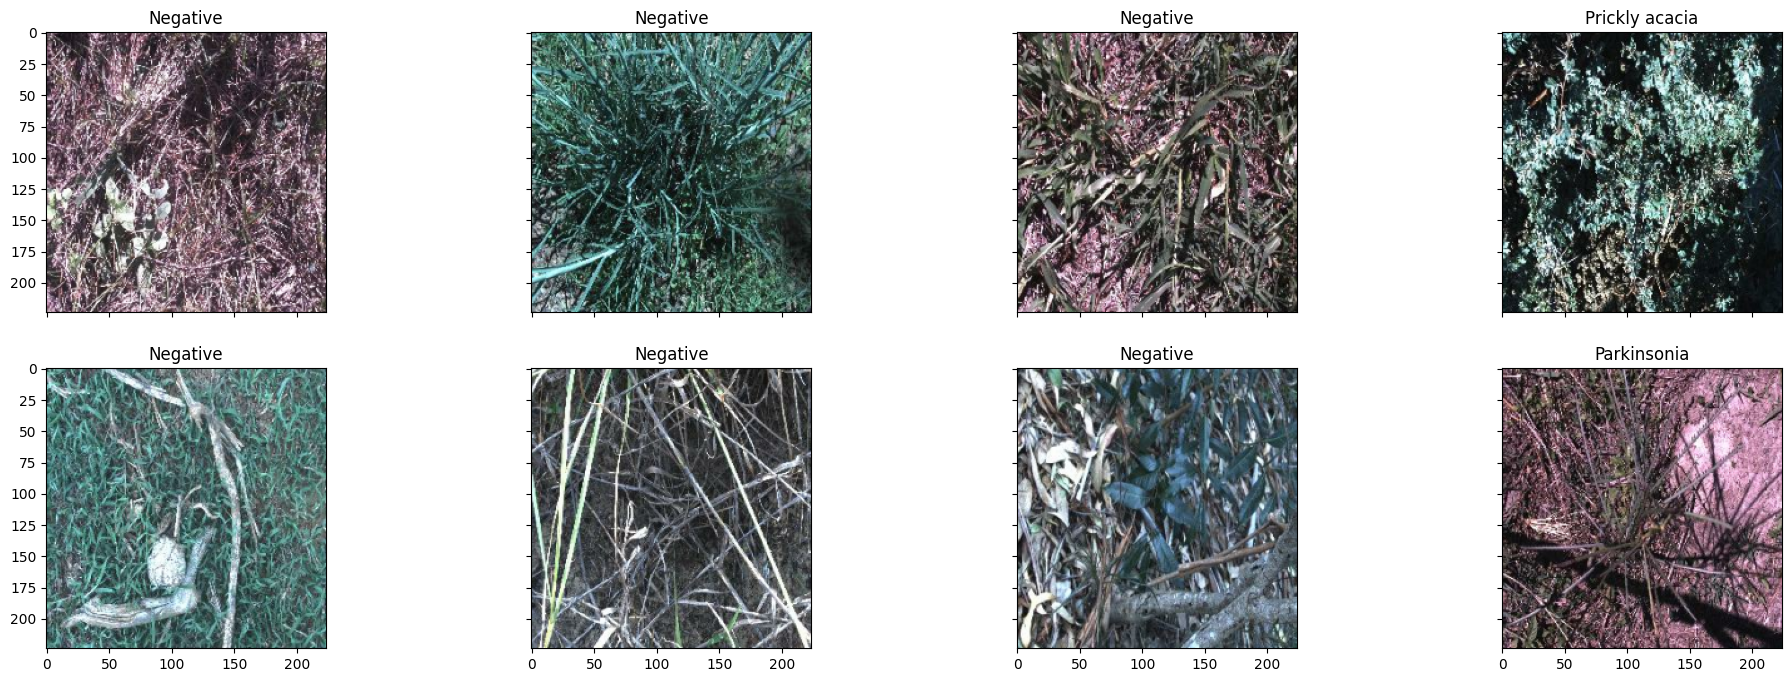

In [16]:
#image visualization
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, sharex=True, sharey=True, figsize=(24,8))

for images, labels in validation_generator:
    for i in range(2):
        for j in range(4):
            ax[i][j].imshow(images[i+j*2].numpy().astype(np.int32))
            ax[i][j].set_title(id2label[np.argmax(labels[i+j*2])])

    break
plt.show()

In [17]:
import tensorflow as tf
import tensorflow.keras as keras
import tensorflow.keras.layers as layers
from tensorflow.keras.layers import GlobalAveragePooling2D, GlobalMaxPooling2D, MaxPool2D, Reshape, \
                        Dense, multiply, Permute, Concatenate, Conv2D, Add, Activation, Lambda, Average
from tensorflow.keras import backend as K
from tensorflow.keras.activations import sigmoid, softmax

def hard_sigmoid(x):
    relu6 = layers.ReLU(max_value=6)
    return relu6(x + 3) / 6
    
def hard_swish(x):
    return x * hard_sigmoid(x)

def GlobalAverageOfMaximums(x, max_pool_size=2, layer_num=1, keep_out_dims=False):
    _max = layers.MaxPooling2D(pool_size=max_pool_size,padding='same', name="Maximums_L{}".format(layer_num))(x)
    _avg = layers.GlobalAveragePooling2D(name="Average_of_Maximums_L{}".format(layer_num), keepdims=keep_out_dims)(_max)
    return _avg

# ConvSelfAt10tion

In [18]:
class TiledUpSampler2D(tf.keras.layers.Layer):
    def __init__(self, **kwargs): ## pooling method: avg | max
        super().__init__(**kwargs)

    def build(self, input_shape):
        assert len(input_shape) == 4 ## asserting the input shape is [batch_size, height, width, channel]
        super().build(input_shape)

    def call(self, x):
        shape = x.shape

        pad = shape[2]//2
        t = shape[2] - pad
        w = shape[2] + (2*pad)
        h = shape[1]
        
        _x = tf.tile(x,tf.constant([1,1,3,1]))
        _x = tf.image.crop_to_bounding_box(_x, 0, t, h, w)

        pad = shape[1]//2
        h = shape[1] + (2*pad)
        t = shape[1] - pad
        _x = tf.tile(_x,tf.constant([1,3,1,1]))
        _x = tf.image.crop_to_bounding_box(_x, t, 0, h, w)
        
        return _x


def ConvSelfAt10tion(in_x, dropout=0.05, regularizer=keras.regularizers.L1L2(0.01,0.01)):
    in_x = tf.keras.layers.Dropout(dropout, seed=SEED)(in_x)
    avg_x = tf.keras.layers.Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(in_x)
    max_x = tf.keras.layers.Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(in_x)
    x = tf.keras.layers.Concatenate(axis=-1)([avg_x, max_x])
    x = layers.Dropout(dropout, seed=SEED)(x)
    
    # upsampler = TiledUpSampler2D()
    # x = upsampler(x)
    
    padding = 'same' if x.shape[1] == in_x.shape[1] else None
    q = tf.keras.layers.Conv2D(1, in_x.shape[1], padding=padding, activation='sigmoid', use_bias=False, kernel_initializer=tf.keras.initializers.HeUniform(SEED))(x)

    k = tf.keras.layers.Conv2D(in_x.shape[-1], 3, padding='same', groups=in_x.shape[-1], use_bias=False, kernel_initializer=tf.keras.initializers.HeUniform(SEED), kernel_regularizer=regularizer)(in_x)
    
    x = k * q
    return x

In [19]:
def subSpaceBottleneckFCLayer(in_shape, n_spaces = 8, out_feat_size = 1024, regularizer = keras.regularizers.L1L2(0.01,0.01)):
    final_out = out_feat_size // n_spaces
    interm_out = final_out*2

    reshape = (n_spaces, in_shape[-1]//n_spaces)
    reshape = reshape if len(in_shape[1:]) == 1 else (*in_shape[1:-1], *reshape)

    bottleneck_layer = keras.Sequential([
        layers.Input(in_shape[1:]),
        layers.Reshape(reshape, name="SubspaceFC_Reshape"),
        layers.Dense(final_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Base"),
        layers.Dense(interm_out, activation='relu', use_bias=False, kernel_initializer=keras.initializers.HeUniform(seed), name="SubspaceFC_Bottleneck_Expand"),
        layers.Dense(final_out, use_bias=False, kernel_regularizer=regularizer, name="SubspaceFC_Bottleneck_Compress"),
        layers.Dropout(0.3, seed=SEED, name="SubspaceFC_Dropout"),
        layers.Reshape((*in_shape[1:-1], out_feat_size), name="SubspaceFC_Out_Reshape"),
    ], name='Subspace_Bottleneck_FCLayer')
    bottleneck_layer.summary()
    
    return bottleneck_layer
    

# Building MobileNet Model

In [20]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large
from tensorflow.keras.applications import EfficientNetV2S, ConvNeXtSmall

def augment(seed=42):
    augs = [] if isTPU else [layers.RandomRotation(0.5, seed=seed, name='RR_Rot'), 
                            layers.RandomTranslation(0.4, 0.4, seed=seed, name='RR_Trans'),
                            layers.RandomZoom(0.2, 0.2, seed=seed, name='RR_Zoom'),] ## can't run with TPU
    
    aug_model = keras.Sequential([
        layers.Input(IMG_SIZE),
        layers.RandomBrightness(0.3, (0, 1),seed=seed, name='RR_Bright'),
        # layers.RandomContrast(0.3, seed=seed, name='RR_Contr'), # can't run deterministically
        layers.RandomFlip(seed=seed, name='RR_Flip'),
        *augs,
        layers.GaussianNoise(0.01, seed=SEED, name='RR_GNoise'),
        # layers.GaussianDropout(0.01, seed=seed, name='RR_Gauss'),
    ], name='augment_pipeline')
    aug_model.summary()
    
    return aug_model


def skipAugment(model):
    inputs = keras.Input(shape=IMG_SIZE)
    x = inputs
    for layer in model.layers:
        if 'augment' not in layer.name and 'input' not in layer.name:
            x = layer(x)

    model = keras.Model(inputs=inputs, outputs=x, name=model.name)
    return model

def MobilenetV3Base(img_size):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    mobilenet = MobileNetV3Small(input_shape=img_size, weights='imagenet', include_preprocessing=False)
    mobilenet.trainable = True

    base_index = 0
    for i in range(len(mobilenet.layers)):
        if('global_average_pooling2d' in mobilenet.layers[i].name):
            base_index = i
            break
            
    out_layer = mobilenet.layers[base_index-1]
    base_model =  keras.Model(inputs=mobilenet.layers[0].output, outputs=out_layer.output, name = mobilenet.name+"_base_")
    base_model.trainable = True
    
    pi0 = base_index+1 # pooler index start
    pi1 = base_index+1 # pooler index end
    for i in range(base_index, len(mobilenet.layers)):
        if('dropout' in mobilenet.layers[i].name):
            pi1 = i - 1 ## Not including dropout --
            break
    
    FCLayer = keras.Model(inputs=mobilenet.layers[pi0].input, outputs=mobilenet.layers[pi1].output, name="MobileNet-FCLayer")
    
    return base_model , FCLayer

def buildModel(IMG_SIZE, skip_preprocess=False):
    # Load the MobileNet model with weights pre-trained on ImageNet.
    base_model, FCLayer = MobilenetV3Base(IMG_SIZE)
    base_model.trainable = True
    FCLayer.trainable = True
    # FCLayer.summary()
    # out_dim = 1024 if "small" in base_model.name.lower() else 1280 if "large" in base_model.name.lower() else base_model.output.shape[-1]

    print("Base Model:", base_model.name)
    print(len(base_model.layers))
    
    # Define the input layer.
    inputs = keras.Input(shape=IMG_SIZE, name='input')

    # Pre-process the input.
    if not skip_preprocess:
        x = layers.Rescaling(1./255, name='PP_Rescale_down')(inputs)
        x = layers.Resizing(IMG_SIZE[0], IMG_SIZE[1], name='PP_Resize')(x)
    
        x = augment(seed)(x)
    else:
        x = inputs
    
    x = base_model(x, training=True)
    x = layers.Dropout(0.3, seed=SEED)(x) 
    x = layers.GlobalAveragePooling2D(keepdims=True)(x)
    x = FCLayer(x)
    x = layers.ActivityRegularization(0.00001, 0.001)(x)
    x = layers.Flatten()(x)
    x = layers.Dropout(0.3, seed=SEED)(x) 
    
    outputs = layers.Dense(9, activation='softmax')(x)
    model_name = "DeepWeeds-" + base_model.name
    
    # Create the model.
    model = keras.Model(inputs=inputs, outputs=outputs, name=model_name)
    return model

In [21]:
with strategy.scope():
    model = buildModel(IMG_SIZE)
model.summary()

10734624/10734624 [==============================] - 0s 0us/step
Base Model: MobilenetV3small_base_
228
Model: "augment_pipeline"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 RR_Bright (RandomBrightnes  (None, 224, 224, 3)       0         
 s)                                                              
                                                                 
 RR_Flip (RandomFlip)        (None, 224, 224, 3)       0         
                                                                 
 RR_Rot (RandomRotation)     (None, 224, 224, 3)       0         
                                                                 
 RR_Trans (RandomTranslatio  (None, 224, 224, 3)       0         
 n)                                                              
                                                                 
 RR_Zoom (RandomZoom)        (None, 224, 224, 3)       0         
            

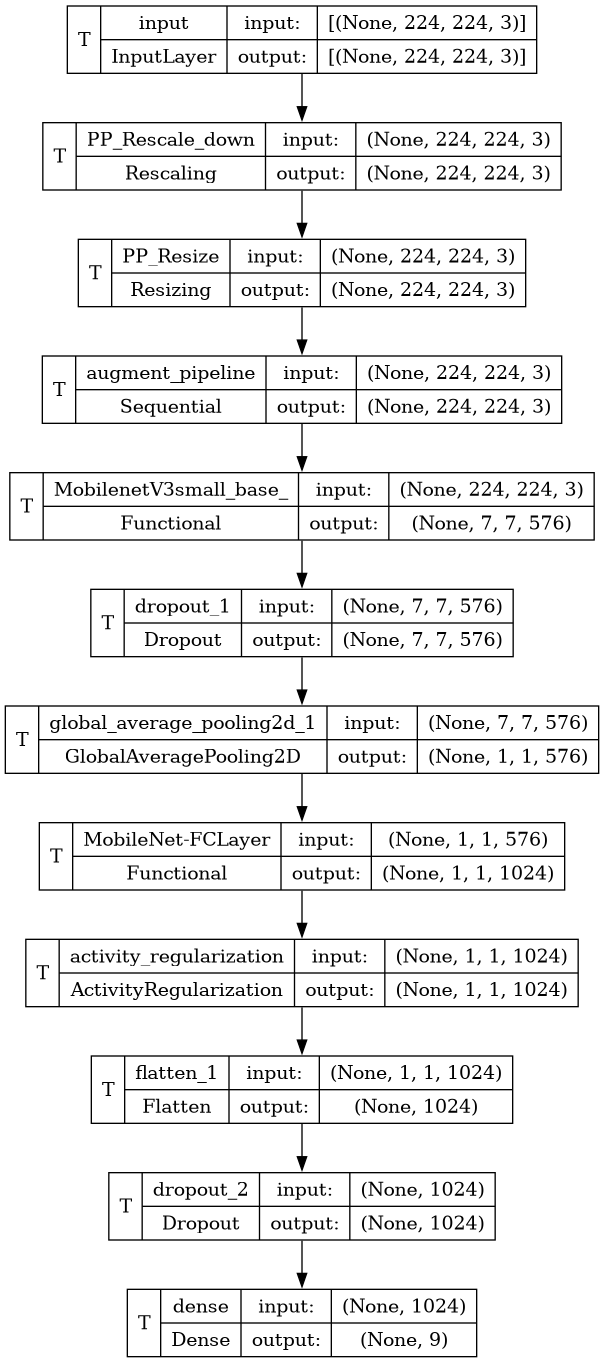

In [22]:
tf.keras.utils.plot_model(model, show_trainable=True, show_layer_names=True, show_shapes=True)

# Trial 1 - FineTuning

In [23]:
from tensorflow.keras.optimizers import Adam, AdamW

checkpoint = tf.keras.callbacks.ModelCheckpoint(MODEL_NAME, save_best_only=True, monitor=ES_MONITOR)
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1, clipnorm=1.0) if not USE_ADAMW else AdamW(learning_rate=(WARMUP_INIT_LR if USE_WARMUP else INIT_LR1),  weight_decay=W_DECAY1)
    
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=['accuracy'])

    early_stopping = tf.keras.callbacks.EarlyStopping(monitor=ES_MONITOR, patience=ES_PATIENCE, verbose=1, restore_best_weights=True)
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR1)

    def createWarmUpScheduler(epochs=5, inc_rate=0.5, init_lr=2e-6, final_lr=2e-5):
        def scheduler(e, lr):
            if e < epochs:
                new_lr =  lr + (lr * inc_rate)
                return new_lr if new_lr < final_lr else final_lr
            elif e == epochs:
                return final_lr
            else:
                return lr

        return scheduler
        
    warmup = keras.callbacks.LearningRateScheduler(createWarmUpScheduler(WARMUP_EPOCHS, WARMUP_INCREMENT_RATE, WARMUP_INIT_LR, INIT_LR1))

    callbacks = [checkpoint, early_stopping, reduce_lr] + ([warmup] if USE_WARMUP else [])
    print(len(callbacks))

print(model.optimizer.get_config())

3
{'name': 'AdamW', 'weight_decay': 0.05, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 0.0002, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/300


2026-01-16 09:03:38.900475: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1768554224.319762      69 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


329/329 [==============================] - 55s 80ms/step - loss: 0.2985 - accuracy: 0.5891 - val_loss: 0.1814 - val_accuracy: 0.7221 - lr: 2.0000e-04
Epoch 2/300
329/329 [==============================] - 23s 70ms/step - loss: 0.1870 - accuracy: 0.6990 - val_loss: 0.1329 - val_accuracy: 0.7838 - lr: 2.0000e-04
Epoch 3/300
329/329 [==============================] - 23s 70ms/step - loss: 0.1487 - accuracy: 0.7487 - val_loss: 0.1083 - val_accuracy: 0.8289 - lr: 2.0000e-04
Epoch 4/300
329/329 [==============================] - 23s 71ms/step - loss: 0.1272 - accuracy: 0.7760 - val_loss: 0.0941 - val_accuracy: 0.8466 - lr: 2.0000e-04
Epoch 5/300
329/329 [==============================] - 23s 70ms/step - loss: 0.1123 - accuracy: 0.7972 - val_loss: 0.0861 - val_accuracy: 0.8543 - lr: 2.0000e-04
Epoch 6/300
329/329 [==============================] - 23s 70ms/step - loss: 0.1003 - accuracy: 0.8095 - val_loss: 0.0782 - val_accuracy: 0.8626 - lr: 2.0000e-04
Epoch 7/300
329/329 [===================

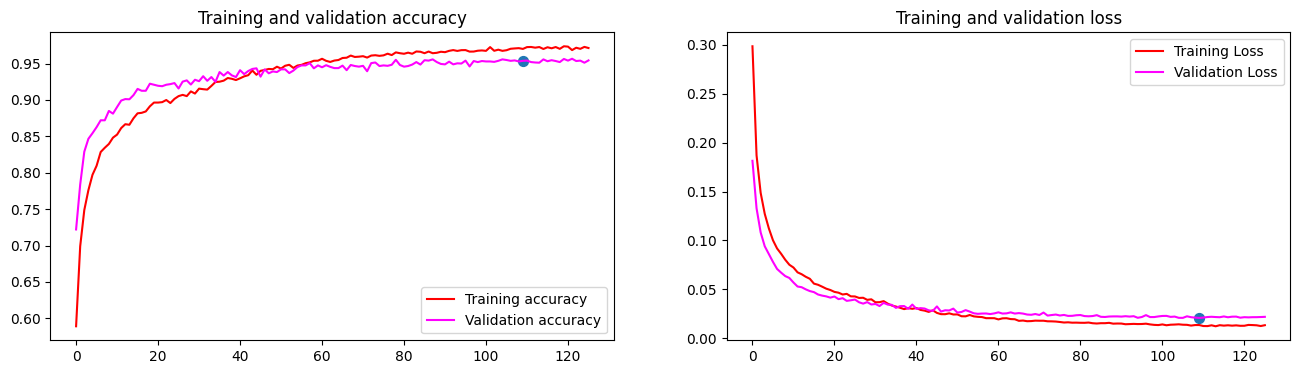

CPU times: user 1h 37min 2s, sys: 6min 7s, total: 1h 43min 9s
Wall time: 48min 21s


In [24]:
%%time
# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=callbacks,
    )

# Plot training results
plot_loss_acc(history1.history)

# Evaluation#1


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 23ms/step - loss: 0.0212 - accuracy: 0.9532
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.87946   0.87556   0.87751       225
       Lantana    0.95146   0.92019   0.93556       213
   Parkinsonia    0.96154   0.97087   0.96618       206
    Parthenium    0.97475   0.94608   0.96020       204
Prickly acacia    0.95305   0.95755   0.95529       212
   Rubber vine    0.96985   0.95545   0.96259       202
     Siam weed    0.96714   0.95814   0.96262       215
    Snake weed    0.90576   0.85222   0.87817       203
      Negative    0.96485   0.97968   0.97221      1821

      accuracy                        0.95544      3501
     macro avg    0.94754   0.93508   0.94115      3501
  weighted avg    0.95522   0.95544   0.95522      3501


                False Positive Rate  Accuracy
Chinee apple               0.008242  0.875556
Lantana                    0.003041  0.920188
Parkinsonia                0.002428  0.970874
Parthenium                 0.001517  0.946078
Prickly acacia    

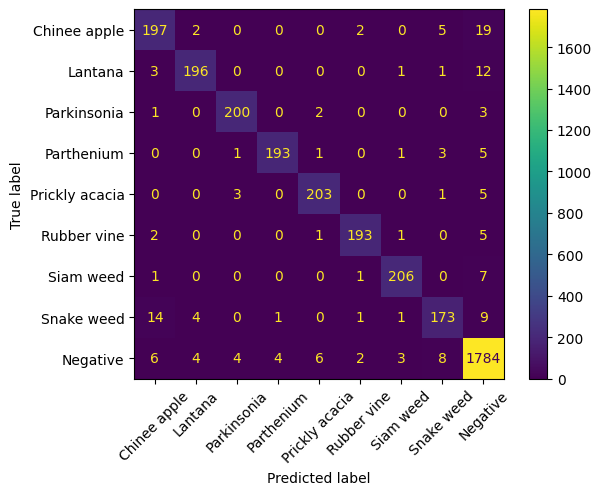


Testn Set Statistics
model.evaluate
110/110 [==============================] - 3s 25ms/step - loss: 0.3154 - accuracy: 0.5241
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.21379   0.13717   0.16712       226
       Lantana    0.39706   0.12676   0.19217       213
   Parkinsonia    0.54839   0.08213   0.14286       207
    Parthenium    0.30189   0.07805   0.12403       205
Prickly acacia    0.45455   0.09390   0.15564       213
   Rubber vine    0.31250   0.09901   0.15038       202
     Siam weed    0.38961   0.13953   0.20548       215
    Snake weed    0.35443   0.13725   0.19788       204
      Negative    0.55974   0.90505   0.69169      1822

      accuracy                        0.52409      3507
     macro avg    0.39244   0.19987   0.22525      3507
  weighted avg    0.46882   0.52409   0.43970      3507


                False Positive Rate  Accuracy
Chinee apple               0.034746  0.137168
Lantana                    0.012447  0.126761
Parkinsonia                0.004242  0.082126
Parthenium                 0.011205  0.078049
Prickly acacia    

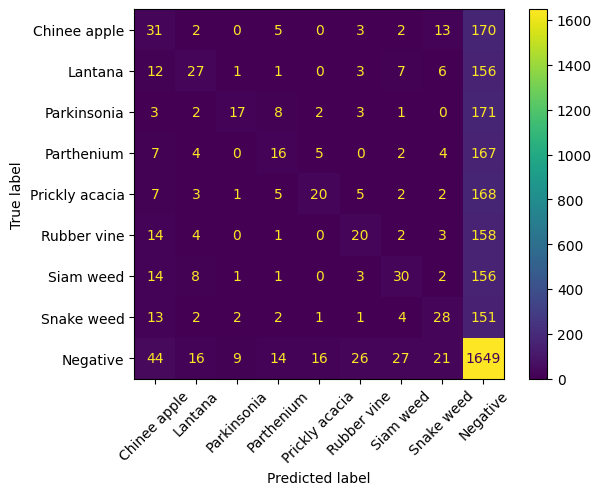

In [25]:
print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

# Freezing Base Model

In [26]:
with strategy.scope():
    for layer in model.layers:
        name = layer.name.lower()
        if 'base' in name:
            print("Freezing layer", layer.name, layer.trainable)
            layer.trainable = False

Freezing layer MobilenetV3small_base_ True


# Evaluations #1.1b

Test After Freezing
Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 23ms/step - loss: 0.0068 - accuracy: 0.9925
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99703   0.99407   0.99555       675
       Lantana    1.00000   0.99686   0.99843       637
   Parkinsonia    0.99037   0.99838   0.99436       618
    Parthenium    0.99352   1.00000   0.99675       613
Prickly acacia    0.99841   0.98744   0.99290       637
   Rubber vine    0.99834   0.99669   0.99752       605
     Siam weed    0.99076   0.99845   0.99459       644
    Snake weed    0.99669   0.99015   0.99341       609
      Negative    0.99726   0.99762   0.99744      5463

      accuracy                        0.99648     10501
     macro avg    0.99582   0.99552   0.99566     10501
  weighted avg    0.99649   0.99648   0.99648     10501


                False Positive Rate  Accuracy
Chinee apple               0.000204  0.994074
Lantana                    0.000000  0.996860
Parkinsonia                0.000607  0.998382
Parthenium                 0.000405  1.000000
Prickly acacia    

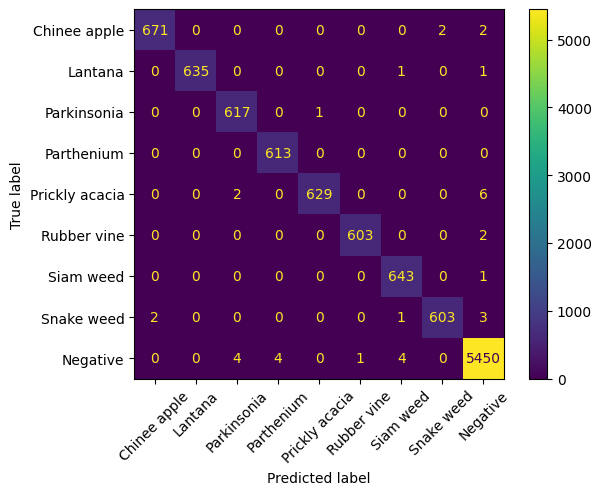

Validation Set Stats
model.evaluate
110/110 [==============================] - 3s 23ms/step - loss: 0.0225 - accuracy: 0.9537
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.91667   0.88000   0.89796       225
       Lantana    0.95192   0.92958   0.94062       213
   Parkinsonia    0.96154   0.97087   0.96618       206
    Parthenium    0.94762   0.97549   0.96135       204
Prickly acacia    0.96172   0.94811   0.95487       212
   Rubber vine    0.98000   0.97030   0.97512       202
     Siam weed    0.95853   0.96744   0.96296       215
    Snake weed    0.92268   0.88177   0.90176       203
      Negative    0.97281   0.98243   0.97760      1821

      accuracy                        0.96201      3501
     macro avg    0.95261   0.94511   0.94871      3501
  weighted avg    0.96176   0.96201   0.96180      3501


                False Positive Rate  Accuracy
Chinee apple               0.005495  0.880000
Lantana                    0.003041  0.929577
Parkinsonia                0.002428  0.970874
Parthenium                 0.003336  0.975490
Prickly acacia    

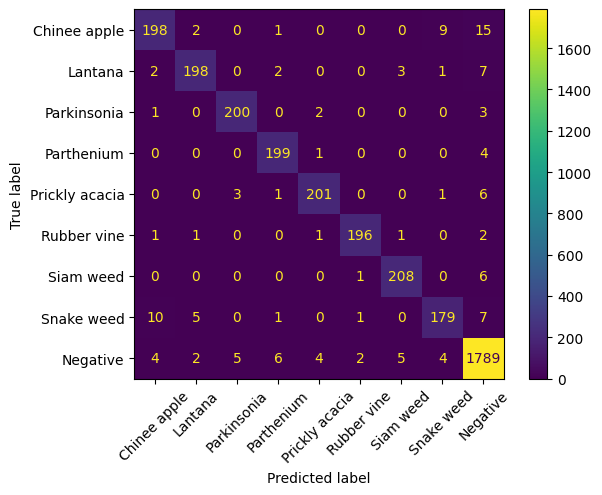

Test Set Stats
model.evaluate
110/110 [==============================] - 3s 27ms/step - loss: 0.3154 - accuracy: 0.5241
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.92202   0.88938   0.90541       226
       Lantana    0.96698   0.96244   0.96471       213
   Parkinsonia    0.95392   1.00000   0.97642       207
    Parthenium    0.93897   0.97561   0.95694       205
Prickly acacia    0.94811   0.94366   0.94588       213
   Rubber vine    0.96447   0.94059   0.95238       202
     Siam weed    0.97653   0.96744   0.97196       215
    Snake weed    0.93909   0.90686   0.92269       204
      Negative    0.97484   0.97805   0.97644      1822

      accuracy                        0.96350      3507
     macro avg    0.95388   0.95156   0.95254      3507
  weighted avg    0.96343   0.96350   0.96336      3507


                False Positive Rate  Accuracy
Chinee apple               0.005181  0.889381
Lantana                    0.002125  0.962441
Parkinsonia                0.003030  1.000000
Parthenium                 0.003937  0.975610
Prickly acacia    

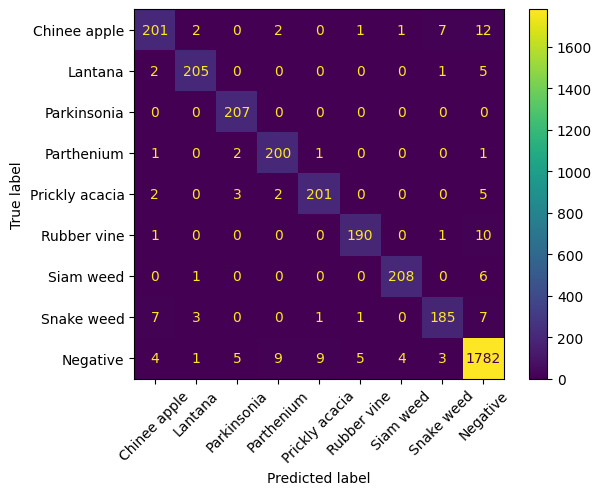

In [27]:
## Test After Freezing
print("Test After Freezing")

print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("Validation Set Stats")        
a, b = eval_model(model, validation_generator)

print("Test Set Stats")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.79468   0.92478   0.85481       226
       Lantana    0.84211   0.97653   0.90435       213
   Parkinsonia    0.95392   1.00000   0.97642       207
    Parthenium    0.93780   0.95610   0.94686       205
Prickly acacia    0.87554   0.95775   0.91480       213
   Rubber vine    0.94030   0.93564   0.93797       202
     Siam weed    0.97196   0.96744   0.96970       215
    Snake weed    0.93909   0.90686   0.92269       204
      Negative    0.98320   0.93139   0.95660      1822

      accuracy                        0.94183      3507
     macro avg    0.91540   0.95072   0.93158      3507
  weighted avg    0.94583   0.94183   0.94268      3507


                False Positive Rate  Accuracy
Chinee apple               0.016458  0.924779
Lantana                    0.011840  0.976526
Parkinsonia                0.003030  1.000000
Parthenium                 0.003937  0.956098
Prickly acacia    

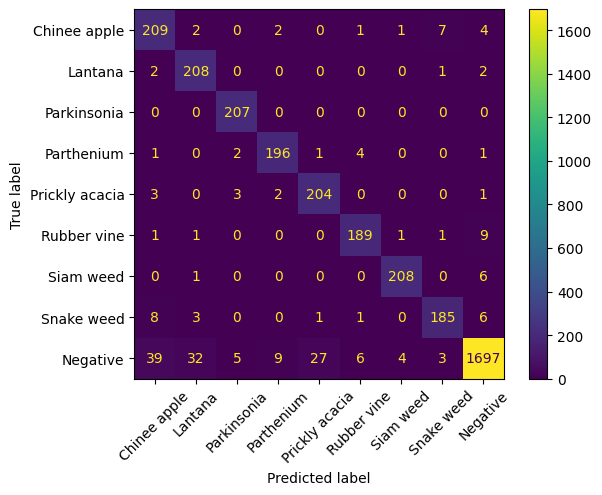

In [28]:
printStats(a,b,0.11)

# Trial 2

In [29]:
with strategy.scope():
    loss = tf.keras.losses.CategoricalFocalCrossentropy()
    optimizer = Adam(learning_rate=INIT_LR2,  weight_decay=W_DECAY2, clipnorm=2.0) if not USE_ADAMW else AdamW(learning_rate=INIT_LR2,  weight_decay=W_DECAY2)
    
    model.compile(loss=loss,
              optimizer=optimizer,
              metrics=['accuracy'])

    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor=ES_MONITOR, factor=LR_REDUCTION_FACTOR, patience=LR_REDUCTION_PATIENCE, verbose=1, min_lr=MIN_LR2)


print(model.optimizer.get_config())

{'name': 'AdamW', 'weight_decay': 0.005, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'jit_compile': True, 'is_legacy_optimizer': False, 'learning_rate': 2e-05, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}


Epoch 1/60


2026-01-16 09:56:13.599374: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inDeepWeeds-MobilenetV3small_base_/dropout_1/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


329/329 [==============================] - 19s 42ms/step - loss: 0.0226 - accuracy: 0.9434 - val_loss: 0.0218 - val_accuracy: 0.9554 - lr: 2.0000e-05
Epoch 2/60
329/329 [==============================] - 13s 38ms/step - loss: 0.0209 - accuracy: 0.9473 - val_loss: 0.0218 - val_accuracy: 0.9577 - lr: 2.0000e-05
Epoch 3/60
329/329 [==============================] - 13s 40ms/step - loss: 0.0209 - accuracy: 0.9485 - val_loss: 0.0222 - val_accuracy: 0.9549 - lr: 2.0000e-05
Epoch 4/60
328/329 [============================>.] - ETA: 0s - loss: 0.0195 - accuracy: 0.9518
Epoch 4: ReduceLROnPlateau reducing learning rate to 1.5999999595806004e-05.
329/329 [==============================] - 13s 38ms/step - loss: 0.0195 - accuracy: 0.9518 - val_loss: 0.0223 - val_accuracy: 0.9543 - lr: 2.0000e-05
Epoch 5/60
329/329 [==============================] - 13s 39ms/step - loss: 0.0187 - accuracy: 0.9545 - val_loss: 0.0218 - val_accuracy: 0.9580 - lr: 1.6000e-05
Epoch 6/60
329/329 [========================

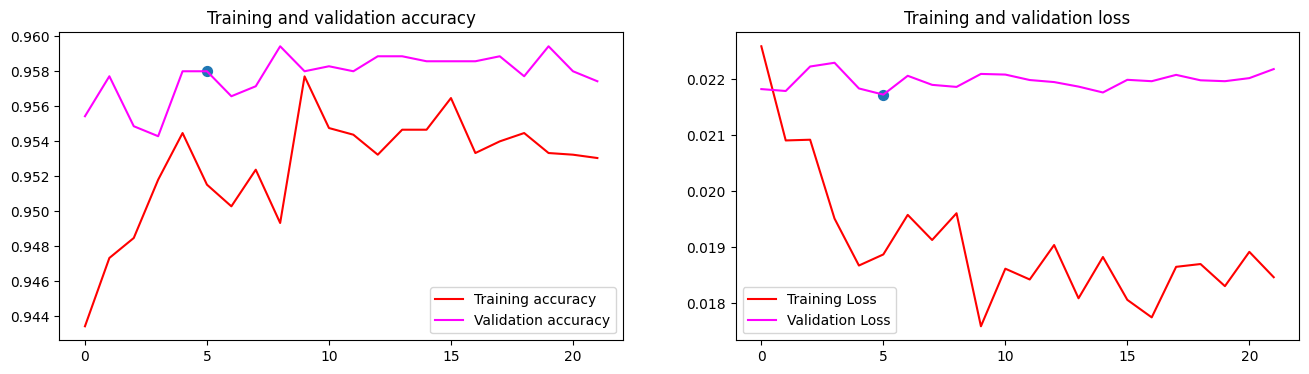

In [30]:
# Train the model
history2 = model.fit(
      train_generator,
      epochs=EPOCHS//5,
      validation_data=validation_generator,
      callbacks=[early_stopping,reduce_lr]
    )

print("Saving the Checkpoint")
model.save("At10tion-"+MODEL_NAME)

# Plot training results
plot_loss_acc(history2.history)


# Accuracy / Loss Plots

Total Epochs: range(0, 148)


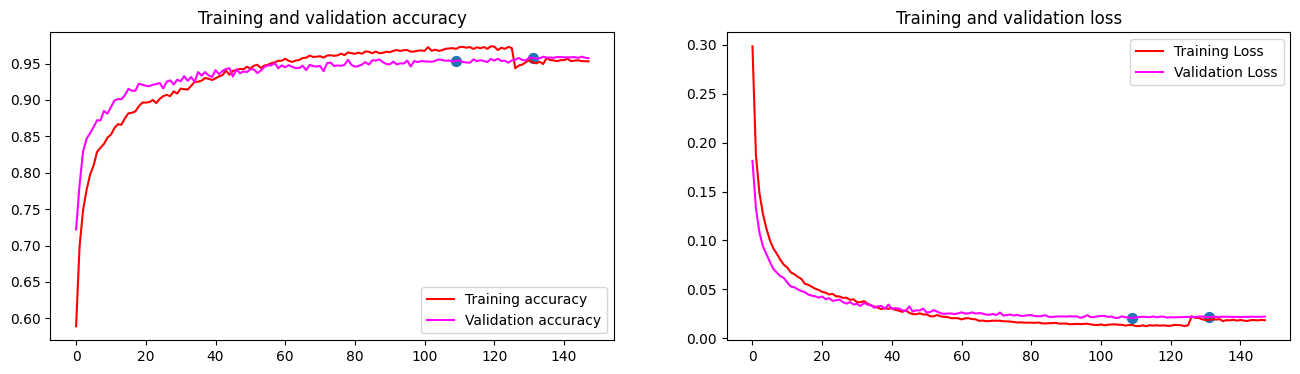

In [31]:
import copy

history = copy.deepcopy(history1.history)

for key in history:
    history[key].extend(history2.history[key])


h1len = len(history1.history['accuracy'])
h2len = len(history2.history['accuracy'])

pat_es = ES_PATIENCE + 1
history['peaks'] = [h1len-pat_es, (h1len+h2len)-pat_es]
history['peaks'] = [i if i>=0 else 0 for i in history['peaks']]

plot_loss_acc(history)

Total Epochs: range(0, 126)


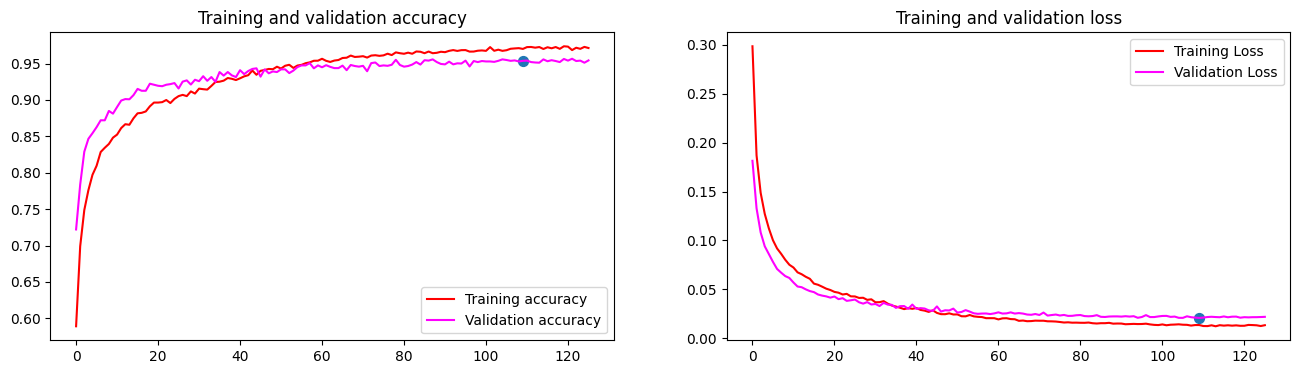

Total Epochs: range(0, 22)


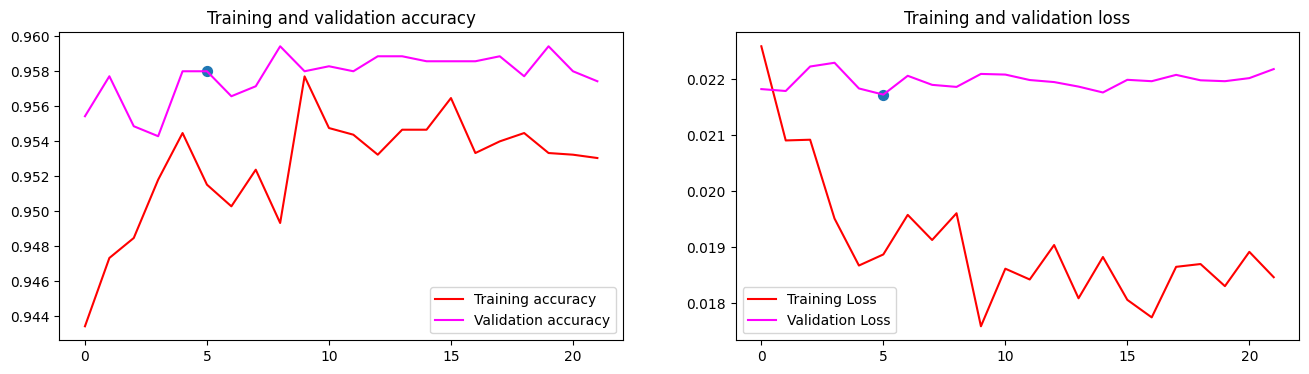

In [32]:
plot_loss_acc(history1.history)
plot_loss_acc(history2.history)

# Evaluation#2

Train Set Statistics
model.evaluate
329/329 [==============================] - 8s 22ms/step - loss: 0.0066 - accuracy: 0.9945
model.predict


  0%|          | 0/329 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.99850   0.98815   0.99330       675
       Lantana    1.00000   0.99058   0.99527       637
   Parkinsonia    0.99197   1.00000   0.99597       618
    Parthenium    0.99835   0.98858   0.99344       613
Prickly acacia    0.98602   0.99686   0.99141       637
   Rubber vine    0.99179   0.99835   0.99506       605
     Siam weed    0.97576   1.00000   0.98773       644
    Snake weed    0.98532   0.99179   0.98854       609
      Negative    0.99780   0.99469   0.99624      5463

      accuracy                        0.99448     10501
     macro avg    0.99172   0.99433   0.99300     10501
  weighted avg    0.99453   0.99448   0.99448     10501


                False Positive Rate  Accuracy
Chinee apple               0.000102  0.988148
Lantana                    0.000000  0.990581
Parkinsonia                0.000506  1.000000
Parthenium                 0.000101  0.988581
Prickly acacia    

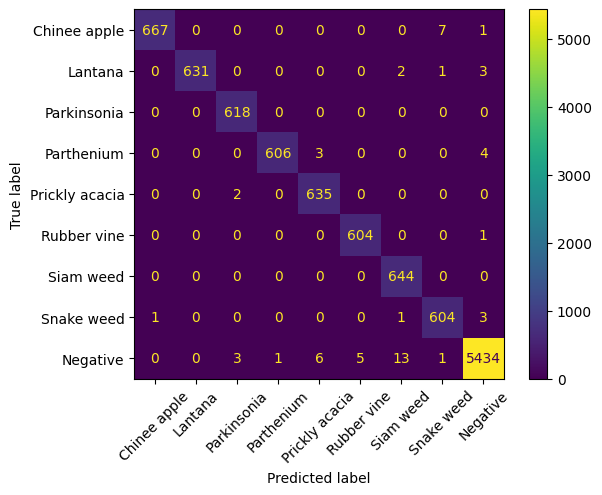


Validation Set Statistics
model.evaluate
110/110 [==============================] - 3s 21ms/step - loss: 0.0217 - accuracy: 0.9580
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93269   0.86222   0.89607       225
       Lantana    0.95631   0.92488   0.94033       213
   Parkinsonia    0.94787   0.97087   0.95923       206
    Parthenium    0.95588   0.95588   0.95588       204
Prickly acacia    0.95261   0.94811   0.95035       212
   Rubber vine    0.98000   0.97030   0.97512       202
     Siam weed    0.90909   0.97674   0.94170       215
    Snake weed    0.90099   0.89655   0.89877       203
      Negative    0.97319   0.97694   0.97506      1821

      accuracy                        0.95801      3501
     macro avg    0.94540   0.94250   0.94361      3501
  weighted avg    0.95809   0.95801   0.95786      3501


                False Positive Rate  Accuracy
Chinee apple               0.004274  0.862222
Lantana                    0.002737  0.924883
Parkinsonia                0.003338  0.970874
Parthenium                 0.002730  0.955882
Prickly acacia    

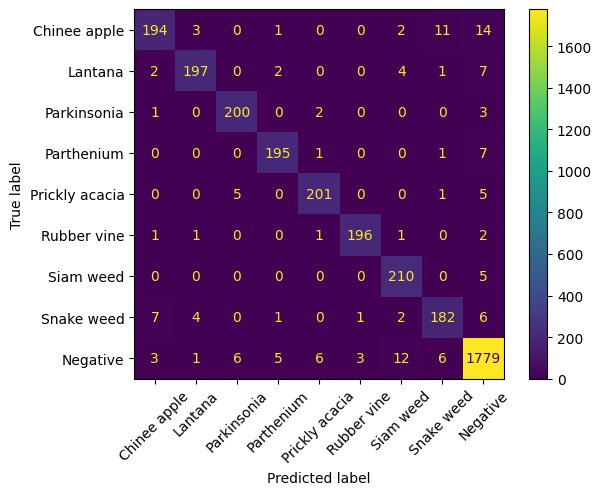


Testn Set Statistics
model.evaluate
110/110 [==============================] - 3s 21ms/step - loss: 0.0182 - accuracy: 0.9584
model.predict


  0%|          | 0/110 [00:00<?, ?it/s]

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.93810   0.87168   0.90367       226
       Lantana    0.96117   0.92958   0.94511       213
   Parkinsonia    0.94954   1.00000   0.97412       207
    Parthenium    0.96078   0.95610   0.95844       205
Prickly acacia    0.93548   0.95305   0.94419       213
   Rubber vine    0.95522   0.95050   0.95285       202
     Siam weed    0.89451   0.98605   0.93805       215
    Snake weed    0.91176   0.91176   0.91176       204
      Negative    0.97790   0.97146   0.97467      1822

      accuracy                        0.95837      3507
     macro avg    0.94272   0.94780   0.94476      3507
  weighted avg    0.95880   0.95837   0.95831      3507


                False Positive Rate  Accuracy
Chinee apple               0.003962  0.871681
Lantana                    0.002429  0.929577
Parkinsonia                0.003333  1.000000
Parthenium                 0.002423  0.956098
Prickly acacia    

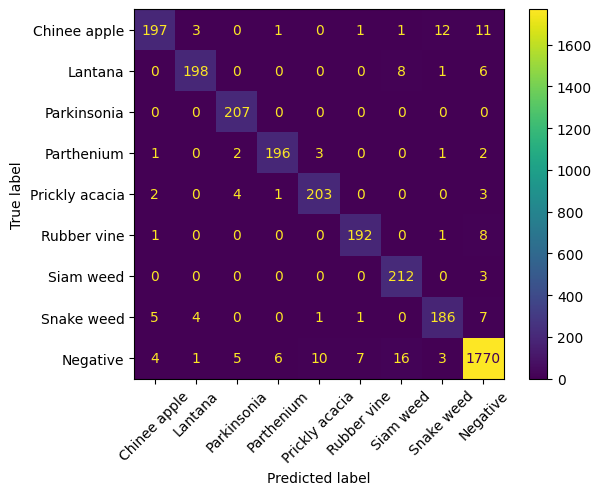

In [33]:
print("Train Set Statistics")
a, b = eval_model(model, train_generator)

print("\nValidation Set Statistics")
a, b = eval_model(model, validation_generator)

print("\nTestn Set Statistics")
a, b = eval_model(model, test_generator)

Evaluation Metrics

                precision    recall  f1-score   support

  Chinee apple    0.81928   0.90265   0.85895       226
       Lantana    0.85957   0.94836   0.90179       213
   Parkinsonia    0.94931   0.99517   0.97170       207
    Parthenium    0.95939   0.92195   0.94030       205
Prickly acacia    0.84647   0.95775   0.89868       213
   Rubber vine    0.91707   0.93069   0.92383       202
     Siam weed    0.87967   0.98605   0.92982       215
    Snake weed    0.90732   0.91176   0.90954       204
      Negative    0.98486   0.92810   0.95564      1822

      accuracy                        0.93584      3507
     macro avg    0.90255   0.94250   0.92114      3507
  weighted avg    0.93972   0.93584   0.93663      3507


                False Positive Rate  Accuracy
Chinee apple               0.013715  0.902655
Lantana                    0.010018  0.948357
Parkinsonia                0.003333  0.995169
Parthenium                 0.002423  0.921951
Prickly acacia    

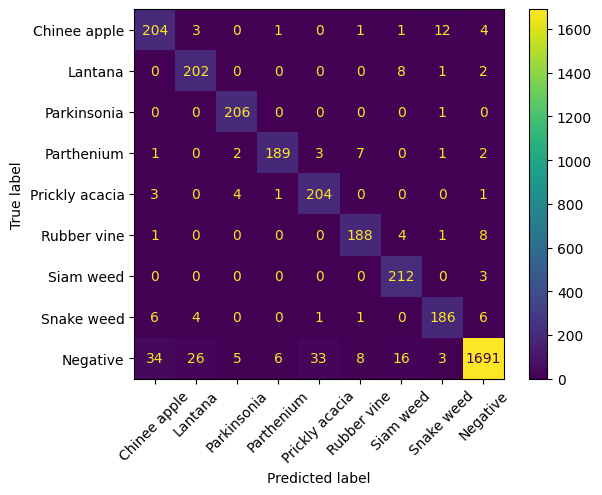

In [34]:
printStats(a,b,0.11)

## Clear Files

In [35]:
shutil.rmtree(base_dir)